<a href="https://colab.research.google.com/github/scudilio/FIAP_MBA-Feature_Engineering/blob/main/aula4_features_engineering_projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn (Telecom/IBM) com Árvore de Decisão — **sem Pipeline do scikit-learn**
Este notebook faz **uma etapa por vez**, com código simples e explícito:

1. Carregar dados  
2. Limpeza mínima (tipos)  
3. EDA (missing/outliers)  
4. **Criar missing artificial** (se necessário)  
5. Tratar outliers (clip q1%/q99%)  
6. Separar treino/teste  
7. Imputação (média/moda) **e** (KNN para numéricas)  
8. One-Hot Encoding (get_dummies)  
9. StandardScaler (numéricas)  
10. Redução por correlação (numéricas)  
11. Redução por RandomForest (importância)  
12. GridSearch manual para DecisionTree  
13. Métricas  
14. Salvar pickle + “deploy” simples (função de probabilidade de churn)


## 1) Setup


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2) Carregar dataset


In [ ]:
# df_work.to_csv('telco-customer-churn_ibm.csv',index =False)

In [ ]:
# Dataset IBM Telco Customer Churn (equivalente ao Kaggle)
url = "https://raw.githubusercontent.com/scudilio/FIAP_MBA-Feature_Engineering/refs/heads/main/telco-customer-churn_ibm.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3) Limpeza mínima (tipos)


In [ ]:
# TotalCharges costuma vir como string
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# # Target
target_col = "Churn"
#df[target_col] = df[target_col].map({"Yes": 1, "No": 0})
df[target_col] = df[target_col]
# df.info()


## 4) EDA rápida: missing e distribuição


In [ ]:
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate[missing_rate > 0]


,0
TotalCharges,0.021440
MonthlyCharges,0.019878
PaymentMethod,0.019878
InternetService,0.019878


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,6903.000000,6892.000000,7043.000000
mean,0.162147,32.371149,64.753738,2282.414357,0.265370
std,0.368612,24.559481,30.082222,2268.792398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.550000,396.825000,0.000000
50%,0.000000,29.000000,70.350000,1396.575000,0.000000
75%,0.000000,55.000000,89.850000,3805.137500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Separar colunas
id_col = "customerID"
feature_cols = [c for c in df.columns if c not in [target_col]]
X0 = df[feature_cols].copy()
y = df[target_col].copy()

num_cols = X0.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = [c for c in X0.columns if c not in num_cols]

print("Numéricas:", num_cols)
print("Categóricas:", len(cat_cols))


Numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: 16


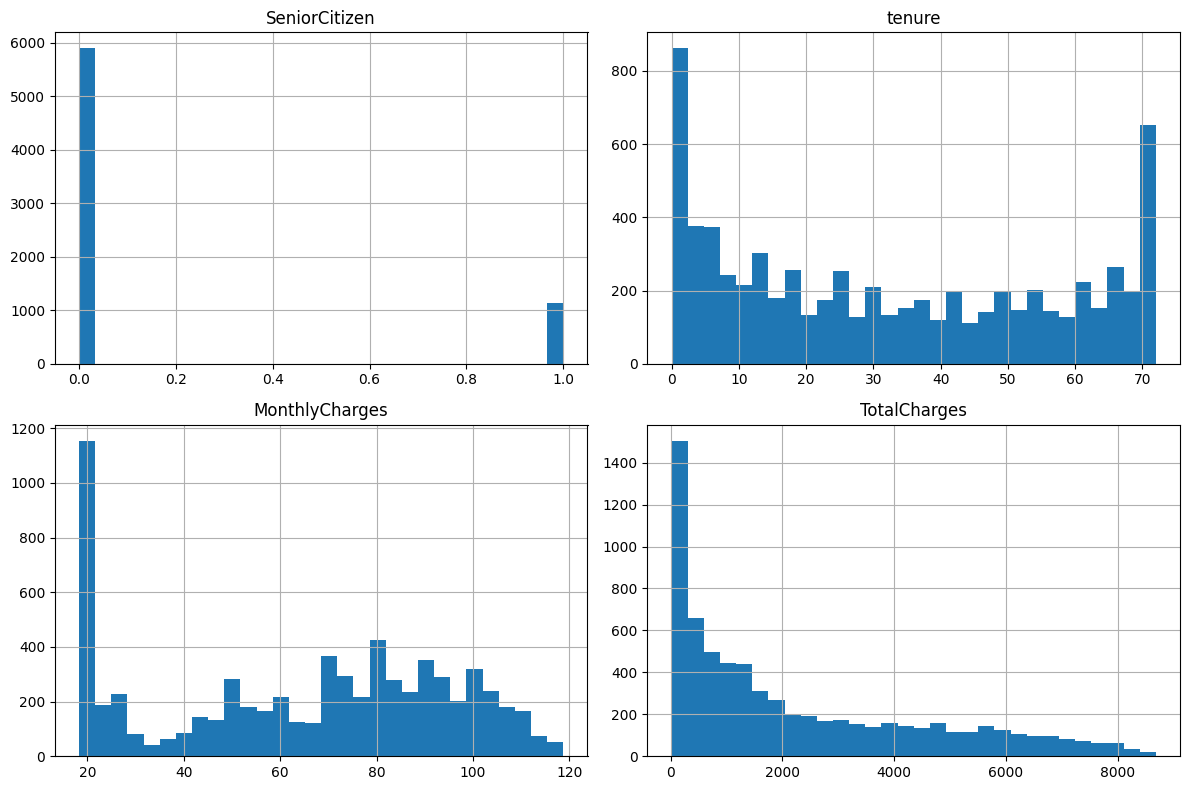

In [ ]:
# Histograma para ver caudas/outliers
X0[num_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()


## 6) Tratar outliers com q1% e q99% (clip nas numéricas)


In [ ]:
def clip_outliers(df_in: pd.DataFrame, numeric_cols, q_low=0.01, q_high=0.99):
    df_out = df_in.copy()
    for c in numeric_cols:
        lo = df_out[c].quantile(q_low)
        hi = df_out[c].quantile(q_high)
        df_out[c] = df_out[c].clip(lo, hi)
    return df_out

# Recalcular colunas (df_work já tem missing)
feature_cols = [c for c in df.columns if c != target_col]
X0 = df[feature_cols].copy()
y = df[target_col].copy()

num_cols = X0.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = [c for c in X0.columns if c not in num_cols]

# Clip
df2 = df.copy()
df2[num_cols] = clip_outliers(df2[num_cols], num_cols, 0.01, 0.99)

# Comparar min/max antes/depois em algumas colunas
compare = pd.DataFrame({
    "min_before": df[num_cols].min(),
    "max_before": df[num_cols].max(),
    "min_after": df2[num_cols].min(),
    "max_after": df2[num_cols].max(),
}).head(10)

compare


,min_before,max_before,min_after,max_after
SeniorCitizen,0.00,1.00,0.0,1.000
tenure,0.00,72.00,1.0,72.000
MonthlyCharges,18.25,118.75,19.2,114.848
TotalCharges,18.80,8684.80,19.9,8042.118


## 7) Train/Test Split


In [ ]:
X = df2.drop(columns=[target_col])
y = df2[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape


((5282, 20), (1761, 20))

## 8) Redução por correlação (apenas numéricas, usando treino)

Regra simples:
- Calcular correlação absoluta no treino (numéricas)
- Para pares com |corr| > 0.90, remover uma coluna


In [ ]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

def correlation_filter(X_num: pd.DataFrame, threshold=0.90):
    corr = X_num.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return to_drop, corr

to_drop_corr, corr_mat = correlation_filter(X_train[num_cols], threshold=0.90)
print("Remover por correlação >", 0.90, ":", to_drop_corr)

num_cols_corr = [c for c in num_cols if c not in to_drop_corr]

# Aplicar drop em treino e teste
X_train_corr = X_train.drop(columns=to_drop_corr)
X_test_corr  = X_test.drop(columns=to_drop_corr)

X_train_corr.shape, X_test_corr.shape


Remover por correlação > 0.9 : []


((5282, 20), (1761, 20))

## 9) Imputação — Versão A: Média/Moda (simples)

- Numéricas: preencher com média do treino  
- Categóricas: preencher com moda do treino


In [ ]:
X_train_A = X_train_corr.copy()
X_test_A  = X_test_corr.copy()

# Numéricas (média)
num_means = X_train_A[num_cols_corr].mean()
X_train_A[num_cols_corr] = X_train_A[num_cols_corr].fillna(num_means)
X_test_A[num_cols_corr]  = X_test_A[num_cols_corr].fillna(num_means)

# Categóricas (moda)
cat_modes = X_train_A[cat_cols].mode(dropna=True).iloc[0]
X_train_A[cat_cols] = X_train_A[cat_cols].fillna(cat_modes)
X_test_A[cat_cols]  = X_test_A[cat_cols].fillna(cat_modes)

X_train_A.isna().sum(), X_test_A.isna().sum()


(customerID          0
 gender              0
 SeniorCitizen       0
 Partner             0
 Dependents          0
 tenure              0
 PhoneService        0
 MultipleLines       0
 InternetService     0
 OnlineSecurity      0
 OnlineBackup        0
 DeviceProtection    0
 TechSupport         0
 StreamingTV         0
 StreamingMovies     0
 Contract            0
 PaperlessBilling    0
 PaymentMethod       0
 MonthlyCharges      0
 TotalCharges        0
 dtype: int64,
 customerID          0
 gender              0
 SeniorCitizen       0
 Partner             0
 Dependents          0
 tenure              0
 PhoneService        0
 MultipleLines       0
 InternetService     0
 OnlineSecurity      0
 OnlineBackup        0
 DeviceProtection    0
 TechSupport         0
 StreamingTV         0
 StreamingMovies     0
 Contract            0
 PaperlessBilling    0
 PaymentMethod       0
 MonthlyCharges      0
 TotalCharges        0
 dtype: int64)

## 10) Imputação — Versão B: KNN para numéricas + Moda para categóricas

- Numéricas: KNNImputer treinado no treino  
- Categóricas: moda do treino


In [ ]:
X_train_B = X_train_corr.copy()
X_test_B  = X_test_corr.copy()

# Categóricas: moda (igual A)
cat_modes_B = X_train_B[cat_cols].mode(dropna=True).iloc[0]
X_train_B[cat_cols] = X_train_B[cat_cols].fillna(cat_modes_B)
X_test_B[cat_cols]  = X_test_B[cat_cols].fillna(cat_modes_B)

# Numéricas: KNN
knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
X_train_B[num_cols_corr] = knn_imputer.fit_transform(X_train_B[num_cols_corr])
X_test_B[num_cols_corr]  = knn_imputer.transform(X_test_B[num_cols_corr])

X_train_B.isna().sum().sum(), X_test_B.isna().sum().sum()


(np.int64(0), np.int64(0))

## 11) One-Hot Encoding (get_dummies) — mantendo consistência treino/teste


In [ ]:
def one_hot_align(train_df: pd.DataFrame, test_df: pd.DataFrame, cat_cols):
    train_ohe = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    test_ohe  = pd.get_dummies(test_df, columns=cat_cols, drop_first=False)
    train_ohe, test_ohe = train_ohe.align(test_ohe, join="left", axis=1, fill_value=0)
    return train_ohe, test_ohe

X_train_A_ohe, X_test_A_ohe = one_hot_align(X_train_A, X_test_A, cat_cols)
X_train_B_ohe, X_test_B_ohe = one_hot_align(X_train_B, X_test_B, cat_cols)

X_train_A_ohe.shape, X_train_B_ohe.shape


((5282, 5327), (5282, 5327))

## 12) StandardScaler (somente nas colunas numéricas originais)


In [ ]:
def scale_numeric(train_df, test_df, numeric_cols_present):
    scaler = StandardScaler()
    train_df = train_df.copy()
    test_df = test_df.copy()

    scaler.fit(train_df[numeric_cols_present])
    train_df[numeric_cols_present] = scaler.transform(train_df[numeric_cols_present])
    test_df[numeric_cols_present]  = scaler.transform(test_df[numeric_cols_present])

    return train_df, test_df, scaler

# Após OHE, as numéricas ainda existem com os mesmos nomes
X_train_A_scaled, X_test_A_scaled, scaler_A = scale_numeric(X_train_A_ohe, X_test_A_ohe, num_cols_corr)
X_train_B_scaled, X_test_B_scaled, scaler_B = scale_numeric(X_train_B_ohe, X_test_B_ohe, num_cols_corr)

X_train_A_scaled.shape, X_train_B_scaled.shape


((5282, 5327), (5282, 5327))

## 13) Seleção de features com RandomForest

- Treina um RF no treino
- Seleciona as features com importância acima da **mediana**


In [ ]:
def rf_feature_select(X_train, y_train, X_test, random_state=RANDOM_STATE, n_estimators=400):
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
    rf.fit(X_train, y_train)

    importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    thr = importances.median()
    selected = importances[importances >= thr].index.tolist()

    X_train_sel = X_train[selected].copy()
    X_test_sel  = X_test[selected].copy()

    return X_train_sel, X_test_sel, rf, importances, thr

X_train_A_sel, X_test_A_sel, rf_A, imp_A, thr_A = rf_feature_select(X_train_A_scaled, y_train, X_test_A_scaled)
X_train_B_sel, X_test_B_sel, rf_B, imp_B, thr_B = rf_feature_select(X_train_B_scaled, y_train, X_test_B_scaled)

print("A: features antes/depois:", X_train_A_scaled.shape[1], "->", X_train_A_sel.shape[1], "| thr:", thr_A)
print("B: features antes/depois:", X_train_B_scaled.shape[1], "->", X_train_B_sel.shape[1], "| thr:", thr_B)

imp_A.head(15)


A: features antes/depois: 5327 -> 2664 | thr: 2.7821044228400737e-05
B: features antes/depois: 5327 -> 2664 | thr: 2.797609136828245e-05


,0
TotalCharges,0.082531
tenure,0.080271
MonthlyCharges,0.070018
Contract_Month-to-month,0.041044
TechSupport_No,0.023946
OnlineSecurity_No,0.023479
Contract_Two year,0.023265
InternetService_Fiber optic,0.020861
PaymentMethod_Electronic check,0.020288
OnlineBackup_No,0.017606


## 14) Ajuste de hiperparâmetros da Decision Tree (GridSearch manual simples)


In [ ]:
from itertools import product

def manual_grid_search_dt(Xtr, ytr, Xte, yte, grid, random_state=RANDOM_STATE):
    best = {"auc": -1, "params": None, "model": None}

    keys = list(grid.keys())
    values = [grid[k] for k in keys]

    for combo in product(*values):
        params = dict(zip(keys, combo))
        model = DecisionTreeClassifier(random_state=random_state, **params)
        model.fit(Xtr, ytr)

        proba = model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, proba)

        if auc > best["auc"]:
            best = {"auc": auc, "params": params, "model": model}

    return best

grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [ 3, 5, 7, 10],
    "min_samples_split": [ 10, 20],
    "min_samples_leaf": [ 5, 10],
    "class_weight": ["balanced"]
}

best_A = manual_grid_search_dt(X_train_A_sel, y_train, X_test_A_sel, y_test, grid)
best_B = manual_grid_search_dt(X_train_B_sel, y_train, X_test_B_sel, y_test, grid)

print("Best AUC (A - média/moda):", best_A["auc"])
print("Params A:", best_A["params"])

print("\nBest AUC (B - KNN):", best_B["auc"])
print("Params B:", best_B["params"])


Best AUC (A - média/moda): 0.8290983918530261
Params A: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 10, 'class_weight': 'balanced'}

Best AUC (B - KNN): 0.8302162178263043
Params B: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5, 'class_weight': 'balanced'}


## 15) Avaliação completa (modelo vencedor)


=== Winner: B_knn_numeric_mode_cat ===
ROC AUC: 0.8302162178263043

Classification report:
              precision    recall  f1-score   support

           0     0.8888    0.7597    0.8192      1294
           1     0.5252    0.7366    0.6132       467

    accuracy                         0.7535      1761
   macro avg     0.7070    0.7481    0.7162      1761
weighted avg     0.7924    0.7535    0.7645      1761

Confusion matrix:
[[983 311]
 [123 344]]


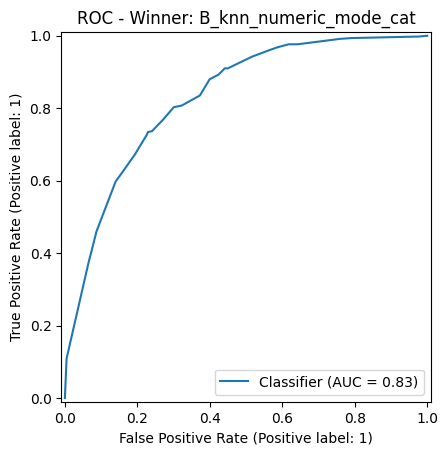

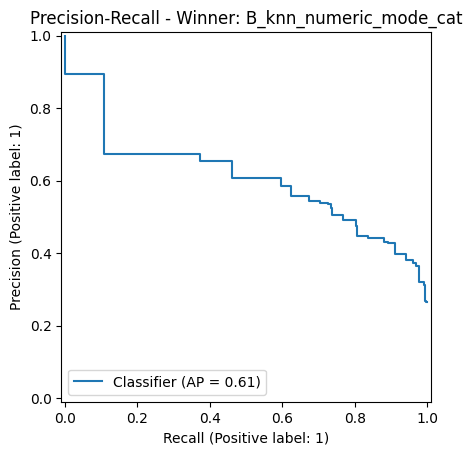

In [ ]:
def evaluate(model, X_test, y_test, title=""):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    auc = roc_auc_score(y_test, proba)

    print(f"=== {title} ===")
    print("ROC AUC:", auc)
    print("\nClassification report:")
    print(classification_report(y_test, pred, digits=4))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))

    RocCurveDisplay.from_predictions(y_test, proba)
    plt.title(f"ROC - {title}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, proba)
    plt.title(f"Precision-Recall - {title}")
    plt.show()

    return auc

if best_A["auc"] >= best_B["auc"]:
    winner_name = "A_simple_mean_mode"
    winner = best_A["model"]
    X_test_w = X_test_A_sel
    X_train_w = X_train_A_sel
    scaler_w = scaler_A
    num_means_w = num_means
    cat_modes_w = cat_modes
    knn_imputer_w = None
    selected_cols_w = X_train_A_sel.columns.tolist()
else:
    winner_name = "B_knn_numeric_mode_cat"
    winner = best_B["model"]
    X_test_w = X_test_B_sel
    X_train_w = X_train_B_sel
    scaler_w = scaler_B
    num_means_w = None
    cat_modes_w = cat_modes_B
    knn_imputer_w = knn_imputer
    selected_cols_w = X_train_B_sel.columns.tolist()

auc_w = evaluate(winner, X_test_w, y_test, f"Winner: {winner_name}")


## 16) Salvar artefatos (pickle) + função de inferência

Salvamos:
- colunas removidas por correlação
- colunas numéricas/categóricas
- estatísticas de imputação (média/moda) ou KNNImputer
- scaler
- lista de colunas finais após seleção RF
- DecisionTree final


In [ ]:
artifacts = {
    "winner_name": winner_name,
    "to_drop_corr": to_drop_corr,
    "num_cols_corr": num_cols_corr,
    "cat_cols": cat_cols,
    "cat_modes": cat_modes_w,
    "num_means": num_means_w,
    "knn_imputer": knn_imputer_w,
    "scaler": scaler_w,
    "selected_cols": selected_cols_w,
    "model": winner
}

model_path = f"churn_dt_no_pipeline_{winner_name}.pkl"
joblib.dump(artifacts, model_path)
print("Salvo em:", model_path)


Salvo em: churn_dt_no_pipeline_B_knn_numeric_mode_cat.pkl


## 17) Deploy simples no notebook: entrada dict -> probabilidade de churn


In [ ]:
loaded = joblib.load(model_path)

def preprocess_one(input_dict: dict, artifacts: dict) -> pd.DataFrame:
    x = pd.DataFrame([input_dict]).copy()

    # 1) Drop correlação
    for c in artifacts["to_drop_corr"]:
        if c in x.columns:
            x = x.drop(columns=[c])

    # 2) Imputação
    num_cols = artifacts["num_cols_corr"]
    cat_cols = artifacts["cat_cols"]

    # Garantir que todas as colunas existam (em inferência pode faltar algo)
    for c in num_cols:
        if c not in x.columns:
            x[c] = np.nan
    for c in cat_cols:
        if c not in x.columns:
            x[c] = np.nan

    # Categóricas (moda)
    x[cat_cols] = x[cat_cols].fillna(artifacts["cat_modes"])

    # Numéricas
    if artifacts["knn_imputer"] is None:
        x[num_cols] = x[num_cols].fillna(artifacts["num_means"])
    else:
        x[num_cols] = artifacts["knn_imputer"].transform(x[num_cols])

    # 3) One-hot
    x_ohe = pd.get_dummies(x, columns=cat_cols, drop_first=False)

    # 4) Scale numéricas
    num_present = [c for c in num_cols if c in x_ohe.columns]
    x_ohe[num_present] = artifacts["scaler"].transform(x_ohe[num_present])

    # 5) Seleção final de colunas (RF selecionou essa lista)
    x_final = x_ohe.reindex(columns=artifacts["selected_cols"], fill_value=0)
    return x_final

def predict_churn_proba(input_dict: dict) -> float:
    X_final = preprocess_one(input_dict, loaded)
    proba = loaded["model"].predict_proba(X_final)[:, 1][0]
    return float(proba)

def predict_churn(input_dict: dict, threshold: float = 0.5) -> dict:
    p = predict_churn_proba(input_dict)
    return {"churn_proba": p, "churn_pred": int(p >= threshold), "threshold": threshold}

# Exemplo de input (ajuste conforme necessário)
example_input = {
    "customerID": "0000-TESTE",
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 420.5
}

predict_churn(example_input, threshold=0.4)


{'churn_proba': 0.8358263036725085, 'churn_pred': 1, 'threshold': 0.4}